# COMBINE ANNOTATIONS

In [1]:
import json
import os


import numpy as np
from pymongo import MongoClient
from datetime import datetime, timezone
from collections import defaultdict, Counter


import networkx as nx
from scipy.optimize import linear_sum_assignment


# keep pixel conversions only

def ensure_pixels(bbox, norm_w, norm_h):
    # if bbox values look normalized (<=1) convert to pixels
    if max(bbox) <= 1.0:
        return [float(bbox[0]) * norm_w, float(bbox[1]) * norm_h, float(bbox[2]) * norm_w, float(bbox[3]) * norm_h]
    return [float(bbox[0]), float(bbox[1]), float(bbox[2]), float(bbox[3])]

def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    unionArea = (boxA[2]-boxA[0])*(boxA[3]-boxA[1]) + (boxB[2]-boxB[0])*(boxB[3]-boxB[1]) - interArea
    return interArea / unionArea if unionArea > 0 else 0


def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter = inter_w * inter_h
    area1 = max(0, (box1[2] - box1[0])) * max(0, (box1[3] - box1[1]))
    area2 = max(0, (box2[2] - box2[0])) * max(0, (box2[3] - box2[1]))
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0

def combine_boxes(boxes, method="mean"):
    """
    boxes: list of [x1, y1, x2, y2]
    """
    boxes = np.array(boxes)

    if method == "mean":
        # Average of all coordinates
        return boxes.mean(axis=0).tolist()

    elif method == "median":
        # More robust to outliers
        return np.median(boxes, axis=0).tolist()

    elif method == "union":
        # Smallest box that contains all boxes
        x1 = boxes[:, 0].min()
        y1 = boxes[:, 1].min()
        x2 = boxes[:, 2].max()
        y2 = boxes[:, 3].max()
        return [x1, y1, x2, y2]

    elif method == "intersection":
        # Largest box contained in all boxes
        x1 = boxes[:, 0].max()
        y1 = boxes[:, 1].max()
        x2 = boxes[:, 2].min()
        y2 = boxes[:, 3].min()
        if x2 < x1 or y2 < y1:
            return None  # no common intersection
        return [x1, y1, x2, y2]


def make_group(group_id, bbox, confidence, label=None):
    return {"groupId": group_id, "bbox": bbox, "confidence": confidence, "label": label}


def make_annotation(video_index, watched, totalwatchtimes, groups, annotation_frame, norm_w, norm_h):
    timestamp = datetime.now(timezone.utc).isoformat()
    return {
        "timestamp": timestamp,
        "videoIndex": video_index,
        "videoFolder": f"videos/clip_{video_index:04d}/",
        "videoWatched": watched,
        "totalWatchTimeMs": totalwatchtimes,
        "numberOfGroups": len(groups),
        "groups": groups,
        "videoInfo": {
            "totalFrames": 50,
            "annotationFrame": annotation_frame,
            "coordinateSystem": "pixel",
            "normalizedWidth": norm_w,
            "normalizedHeight": norm_h
        }
    }

# db connection (reuse existing env vars if present)
MONGO_URI = os.getenv('MONGO_URI', 'mongodb://localhost:27017/')
MONGO_DB = 'video_annotations'
client = MongoClient(MONGO_URI)
db = client[MONGO_DB]
coll = db['finegrained_annotations']

os.makedirs('../results/', exist_ok=True)

# gather video folders
videoFolder = coll.aggregate([
    {"$group": {"_id": "$videoFolder"}},
    {"$sort": {"_id": 1}}
])
video_folders = sorted(set([vid['_id'] for vid in list(videoFolder)]))
#print(video_folders)

root = {"completedAt": datetime.now(timezone.utc).isoformat(), "totalVideos": 0, "annotations": []}

# thresholds
GENERAL_IOU = 0.3
INDIV_IOU = 0.7
iou_threshold = 0.4

jsons_path = '../SEKAI_720_3/jsons_step1/'

fine_total_coincidence, total_coincidence, total_total, fine_total_total = 0, 0, 0, 0

finegrained_annotations_collection = db['finegrained_annotations']

videoFolder = finegrained_annotations_collection.aggregate([
    { "$group": { "_id": "$videoFolder" } },
    { "$sort": { "_id": 1 } }
])

video_folders = sorted(set([vid['_id'] for vid in list(videoFolder)]))

in_box, out_box = 0,0
map_out_bbox = defaultdict(int)
map_in_bbox = defaultdict(int)

for folder in video_folders:
    ind = int(folder.split('_')[1])
    json_file = f'{jsons_path}/{folder}.json'

    with open(json_file, 'r') as f:
        json_data_s1 = json.load(f)

    for frame in [1, 21, 41]:

        current_frame_info={}
        current_frame_info['frame_id'] = frame+1
        current_frame_info['detections'] = []

        
        # fetch groups for this folder/frame and unwind groups
        pipeline = [
            {"$match": {"videoFolder": folder, "videoInfo.annotationFrame": frame}},
            {"$unwind": {"path": "$groups", "preserveNullAndEmptyArrays": False}},
            {"$project": {
                "_id": 0,
                "annotator_id": 1,
                "videoFolder": 1,
                "annotationFrame": "$videoInfo.annotationFrame",
                "bbox": "$groups.bbox",
                "confidence": "$groups.confidence",
                "label": {"$ifNull": ["$groups.name", {"$ifNull": ["$groups.label", ""]} ]}
            }}
        ]
        docs = list(coll.aggregate(pipeline))
        if not docs:
            # no annotations for this frame
            json_data_s1['frames'].append(current_frame_info)
            root["annotations"].append(make_annotation(ind, 0, 0, [], frame, 1920, 1080))
            continue

        # normalization reference from first doc if available
        vi0 = docs[0].get('videoInfo') if 'videoInfo' in docs[0] else {}
        norm_w = vi0.get('normalizedWidth', 1920) if isinstance(vi0, dict) else 1920
        norm_h = vi0.get('normalizedHeight', 1080) if isinstance(vi0, dict) else 1080

        # collect boxes per annotator (ensure pixels)
        per_annot = defaultdict(list)  # annotator -> list of (bbox_px, confidence, label)
        for d in docs:
            aid = d.get('annotator_id', 'anon')
            lbl = d.get('label') or ''
            bbox_raw = d.get('bbox')
            if not bbox_raw or len(bbox_raw) != 4:
                continue
            bbox_px = ensure_pixels(bbox_raw, norm_w, norm_h)
            conf = d.get('confidence', 1.0)
            per_annot[aid].append((bbox_px, conf, lbl))


        # flatten first annotator's boxes and attempt to match across annotators
        all_annotators = list(per_annot.keys())
        groups = []
        gid = 0
        #print(all_annotators)
        
        groupings = []
        total_keys = []
        
        for l_idx, annotator in enumerate(all_annotators):
            seed_boxes = per_annot[annotator]
            ann_to_groups = defaultdict(list)
    
            for idx, (seed_box, seed_conf, seed_group) in enumerate(seed_boxes):
                ann_to_groups[seed_group].append(seed_box)

            groupings.append(ann_to_groups)
            total_keys.extend(groupings[l_idx].keys())
        
        group_labels = list(set(total_keys))
        if 'individual' in group_labels:
            group_labels.remove('individual')
            group_labels.append('individual')
        
        for label in group_labels:


            coincidence = 0
            total = len(groupings)

            
            for grouping in groupings:
                if label in grouping:
                    coincidence +=1

            total_total+=total
            total_coincidence+=coincidence

            all_boxes = []
            if (coincidence/total) >= 0.5:
                bboxes = []
                if label == 'individual':
                    bboxes = [group['bbox'] for group in groups]
                    
                for ann_idx, grouping in enumerate(groupings):
                    for box in grouping[label]:
                        if label == 'individual':
                            max_iou = 0
                            for g_box in bboxes:
                                max_iou = max(max_iou, iou(g_box, box))
                            #print(max_iou)
                            if max_iou <= 0.95:
                                all_boxes.append((all_annotators[ann_idx], box))
                        else:
                            all_boxes.append((all_annotators[ann_idx], box))
                            
            G = nx.Graph()
            for i in range(len(all_boxes)):
                G.add_node(i)
        
            for i in range(len(all_boxes)):
                maximums = defaultdict(int)
                max_ids  = defaultdict(int)

                
                ann_i, box_i = all_boxes[i]
                area = abs(box_i[0] - box_i[2]) * abs(box_i[1] - box_i[3])
                if area < 100*100:
                    iou_threshold = 0.3
                elif area < 500**500:
                    iou_threshold = 0.5
                else:
                    iou_threshold = 0.7
                        
                for j in range(i + 1, len(all_boxes)):
                    ann_j, box_j = all_boxes[j]
        
                    # ✅ Only connect boxes from DIFFERENT annotators

                    if ann_i != ann_j and iou(box_i, box_j) >= iou_threshold:
                        if iou(box_i, box_j) >=  maximums[ann_j]:
                            maximums[ann_j] = iou(box_i, box_j)
                            max_ids[ann_j] = j

                    for j in max_ids.values():
                        G.add_edge(i, j)
        

            clusters = []
            for component in nx.connected_components(G):
                cluster = [all_boxes[i] for i in component]
                annotators_in_cluster = [ann for ann, _ in cluster]
        
                # Optional: flag if same annotator appears twice in a cluster
                # (can happen via transitive connections — see note below)
                clusters.append({
                    "boxes": cluster,
                    "annotators": annotators_in_cluster,
                    "agreement": len(set(annotators_in_cluster))  # how many unique annotators agree
                })

                #print(cluster)
                fine_total_coincidence += len(set(annotators_in_cluster))
                fine_total_total+=coincidence
                if len(set(annotators_in_cluster))/total >= 0.5:
                    in_box +=1
                    cluster_boxes_only = [box for _, box in cluster]
                    box = combine_boxes(cluster_boxes_only, method="mean")

                    groups.append(make_group(gid, box, 1.0, label))
                    if label == 'individual':
                        gid+=1
                    map_in_bbox[label.split('_')[0]]+=1
                else:
                    #print(label)
                    out_box+=1
                    map_out_bbox[label.split('_')[0]]+=1# defaultdict(int)

            gid+=1

        bboxes = [group['bbox'] for group in groups]
        
        for idx, box in enumerate(bboxes):
            current_frame_info['detections'].append({'track_id': idx+1, 'bbox':box})

        
    #     # append annotation

        
        root["annotations"].append(make_annotation(ind, 0, 0, groups, frame, norm_w, norm_h))
    
        json_data_s1['frames'].append(current_frame_info)

    jsons_path2 = jsons_path.replace('jsons_step1','jsons_step2')
    os.makedirs(jsons_path2, exist_ok=True)
    with open(f"{json_file.replace('jsons_step1','jsons_step2')}", "w") as f:
        json.dump(json_data_s1, f, indent=4)


print('In Bboxes:', in_box)
print('Out Bboxes:', out_box)
print(map_in_bbox)
print(map_out_bbox)
print('Total Group Annotations:', total_total)
print('Total Fine Grained Annotations', fine_total_total)
print('Total agreement:', total_coincidence/total_total)
print('Fine grained, total agreement:', fine_total_coincidence/fine_total_total)

#print(root)
# write merged file
with open('../results/finegrained_all_annotations.json', 'w', encoding='utf-8') as f:
    json.dump(root, f, indent=4)


In Bboxes: 24331
Out Bboxes: 1341
defaultdict(<class 'int'>, {'individual': 12518, 'group': 11813})
defaultdict(<class 'int'>, {'individual': 350, 'group': 991})
Total Group Annotations: 16657
Total Fine Grained Annotations 62464
Total agreement: 0.9556943026955634
Fine grained, total agreement: 0.9164478739754098


# READ SBU ANNOTATIONS to generate GT


In [2]:
# READ SBU ANNOTATIONS to generate GT
import json
import pickle
from collections import defaultdict

with open('../results/finegrained_all_annotations.json', 'r') as f:
    data = json.load(f)

counter = 15

all_results = [{},{},{}]
map_r = {1:0, 21:1, 41:2}


#results = {}


for annotations in data['annotations']:

    ann_frame = annotations['videoInfo']['annotationFrame']
    gt_id = map_r[ann_frame]
    idx = annotations['videoIndex']

    if idx not in all_results[gt_id]:
        all_results[gt_id][idx-1] = {}
    
    
    #print(idx)
    #print(ann_frame)
    groups = []
    map_group_members = defaultdict(list)
    
    for idx_person, group in enumerate(annotations['groups']):

        #print(group)
        #print(idx_person)
        
        x1, y1, x2, y2 = group['bbox']
        group_label = group['groupId']
        map_group_members[group_label+1].append(idx_person+1)
        #print(group_label)
        dc  = 1
        lvl = 1
        
        GT_list = [idx-1, 1, int(x1), int(y1), int(x2), int(y2), group_label+1, dc, lvl]
        str_to_be_added = [str(k) for k in GT_list]
        str_to_be_added = (" ".join(str_to_be_added))
        f = open('./gt_sekai_ours_'+str(ann_frame+1)+'.txt', "a+")
        f.write(str_to_be_added + "\r\n")
        f.close()

    
    groups = list(map_group_members.values())
    #print(groups)
    
    all_results[gt_id][idx-1][str(0)] = groups

#print(all_results[2])
if all_results[0]:
    save_path = f"../results/gt_sekai_2.pkl"
    with open(save_path, "wb") as f:
        pickle.dump(all_results[0], f)


if all_results[1]:
    save_path = f"../results/gt_sekai_22.pkl"
    with open(save_path, "wb") as f:
        pickle.dump(all_results[1], f)


if all_results[2]:
    save_path = f"../results/gt_sekai_42.pkl"
    with open(save_path, "wb") as f:
        pickle.dump(all_results[2], f)

    #results[idx]
    #print('')


In [1]:
import json
import pickle
from collections import defaultdict

with open('../results/finegrained_all_annotations.json', 'r') as f:
    data = json.load(f)

counter = 15
num_fine_grained = 0
num_coarse_groups = 0
freq = defaultdict(int)
region_groupsize = defaultdict(list)

with open('file_to_region.pkl', 'rb') as f:
    file_to_region = pickle.load(f)


for annotations in data['annotations']:
    directory_path = annotations['videoFolder']
    
    ann_frame = annotations['videoInfo']['annotationFrame']
    idx = annotations['videoIndex']
    count_groups = defaultdict(int)
    for group in annotations['groups']:
        #print(group)
        if group['label'] != 'individual':
            count_groups[group['label']]+=1
        if group['label'] == 'individual':
            freq[1]+=1
        num_fine_grained+=1

    for count in count_groups:
        freq[count_groups[count]]+=1
        #region_groupsize[file_to_region[directory_path.split('/')[-2]]].append(count_groups[count])
        region_groupsize[file_to_region[directory_path.split('/')[-2]]].append(5 if count_groups[count] >=5 else count_groups[count])
    
    num_coarse_groups+=len(count_groups)


print('Number of Finegrained boxes:', num_fine_grained)
print('Number of Coarse boxes:', num_coarse_groups)

print(freq)

Number of Finegrained boxes: 24331
Number of Coarse boxes: 5151
defaultdict(<class 'int'>, {1: 12795, 2: 3705, 3: 818, 4: 218, 5: 76, 6: 30, 7: 14, 24: 1, 9: 4, 12: 2, 8: 3, 13: 1, 11: 1, 10: 1})


# PLOT ANNOTATED DATA

In [19]:

import json
import cv2
from matplotlib.patches import Rectangle
import numpy as np
import os
import matplotlib.pyplot as plt

os.makedirs("../results/finegrained_fig_annotations", exist_ok=True)

with open('../results/finegrained_all_annotations.json', 'r') as f:
    data = json.load(f)

#print(data)
# Palette aligned with finegrained UI
palette = [
    '#a9a9a9', '#e6194b', '#f58231', '#ffe119', '#bfef45', '#3cb44b',
    '#911eb4', '#f032e6', '#fabed4', '#9a6324', '#800000', '#ffd8b1',
    '#808000', '#fffac8', '#4363d8', '#f4a261', '#e76f51', '#2a9d8f',
    '#8ac926', '#ffca3a', '#ff595e', '#ff924c', '#c77dff', '#7209b7',
    '#b5179e', '#ff006e', '#d62828', '#f77f00', '#fcbf49', '#6a994e'
]

palette = [
    "#808080",  # Gray
    "#FF0000",  # Red
    "#00FF00",  # Green
    "#0000FF",  # Blue
    "#FFFF00",  # Yellow
    "#00FFFF",  # Cyan
    "#FF00FF",  # Magenta
    "#000000",  # Black
    "#FFFFFF",  # White

    "#000080",  # Maroon
    "#008000",  # Dark Green
    "#800000",  # Navy
    "#008080",  # Olive
    "#800080",  # Purple
    "#808000",  # Teal
    "#C0C0C0",  # Silver

    "#FFA500",  # Orange
    "#FFC0CB",  # Pink
    "#A52A2A",  # Brown
    "#71B33C",  # Medium Sea Green
    "#FF1493",  # Deep Pink
    "#32CD32",  # Lime Green
    "#B469FF",  # Hot Pink
    "#8B4513",  # Dark Slate Blue
]

# stable color map per label within this run
color_map = {}
next_color = 0


for idx, annotations in enumerate(data.get('annotations', [])):
    #print(annotations)
    video_index = annotations.get('videoIndex')
    
    directory_path = annotations.get('videoFolder', '')
    frame = annotations['videoInfo'].get('annotationFrame')
    img_path = os.path.join(directory_path, f"{frame+1:05d}.jpeg")
    img_path = '../'+ img_path
    
    image = cv2.imread(img_path)
    if image is None:
        alt = os.path.join(directory_path, f"{frame+1:05d}.jpg")
        image = cv2.imread(alt)
    if image is None:
        print(f"Missing image: {img_path} (and {alt if 'alt' in locals() else 'none'}) - skipping idx={idx}, frame={frame}")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    # Create figure sized so 1 figure point == 1 image pixel at dpi=100
    fig, ax = plt.subplots(figsize=(w/300, h/300), dpi=300)
    ax.imshow(image)

    # Lock axes to pixel coordinates (origin top-left)
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)

    # Draw boxes and labels using pixel coordinates
    #color_map = {}
    #next_color = 0

    for group in annotations.get('groups', []):
        bbox = group.get('bbox', [])
        if len(bbox) != 4:
            continue
        x1, y1, x2, y2 = bbox

        # Convert normalized bbox -> pixel if needed
        coord = annotations['videoInfo'].get('coordinateSystem', '')
        if coord == 'normalized' or max(x1, y1, x2, y2) <= 1.0:
            norm_w = annotations['videoInfo'].get('normalizedWidth', 1920)
            norm_h = annotations['videoInfo'].get('normalizedHeight', 1080)
            px1 = int(round(x1 * norm_w))
            px2 = int(round(x2 * norm_w))
            py1 = int(round(y1 * norm_h))
            py2 = int(round(y2 * norm_h))
        else:
            px1, py1, px2, py2 = int(round(x1)), int(round(y1)), int(round(x2)), int(round(y2))

        group_label = group.get('label', group.get('groupId', 0))
        label_key = str(group_label)
        #if label_key == 'individual':
        #    color_map[label_key] = palette[next_color % len(palette)]
        #    next_color += 1  
        if label_key not in color_map:
            color_map[label_key] = palette[next_color % len(palette)]
            next_color += 1
            
        color = color_map[label_key]

        rect = Rectangle((px1, py1), px2 - px1, py2 - py1, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        #ax.text(px1, max(0, py1 - 6), str(group_label), color='white', fontsize=6, backgroundcolor='black')

    #print('')
    ax.axis('off')
    plt.savefig(f"../results/finegrained_fig_annotations/finegrained_{idx}.pdf", dpi=300, bbox_inches='tight', pad_inches=0)
    plt.close()


KeyboardInterrupt: 

## GROUP SIZES BY REGION

In [ ]:
#print(region_groupsize)

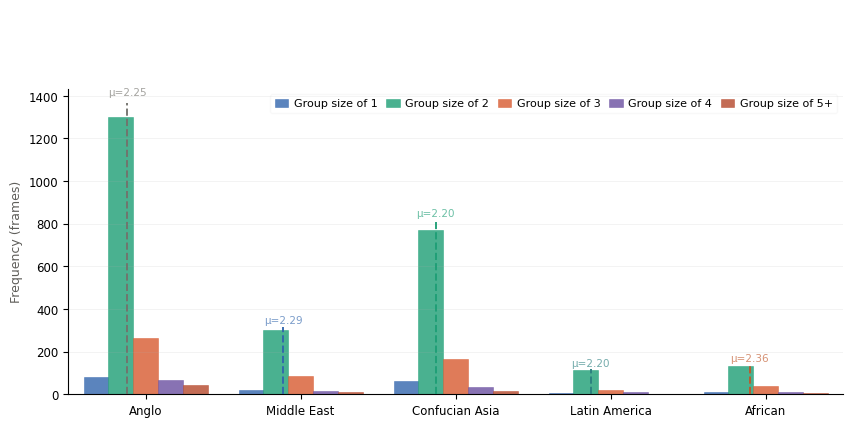

In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import numpy as np

# ── Your data ────────────────────────────────────────────────────────────────
AN  = np.array(region_groupsize['Anglo'])
ME  = np.array(region_groupsize['Middle East'])
CA  = np.array(region_groupsize['Confucian Asia'])
#SEA = np.array(region_confidence['South-East Asia'])
#LE  = np.array(region_confidence['Latin Europe'])
#EE  = np.array(region_confidence['Eastern Europe'])
LA  = np.array(region_groupsize['Latin America'])
#OT  = np.array(region_confidence['Other'])
AF  = np.array(region_groupsize['African'])
#GE  = np.array(region_confidence['Germanic Europe'])
#NE  = np.array(region_confidence['Nordic Europe'])


# ── Config ───────────────────────────────────────────────────────────────────
SCORE_BINS = [1, 2, 3, 4, 5]

SCORE_COLORS = {
    1: ("#3266ad", 0.80),
    2: ("#1D9E75", 0.80),
    3: ("#D85A30", 0.80),
    4: ("#6B4FA0", 0.80),
    5: ("#B5472A", 0.80),
}

GROUP_COLORS = {
    "Anglo":           ("#73726c", 0.65),
    "Middle East":     ("#3266ad", 0.65),
    "Confucian Asia":  ("#1D9E75", 0.65),
    #"South-East Asia": ("#D85A30", 0.65),
    #"Latin Europe":    ("#6B4FA0", 0.65),
    #"Eastern Europe":  ("#B5472A", 0.65),
    "Latin America":   ("#2A7F7F", 0.65),
    #"Other":           ("#A0522D", 0.65),
    "African":         ("#C0572A", 0.65),
    #"Germanic Europe": ("#4A7C3F", 0.65),
    #"Nordic Europe":   ("#7B3F8C", 0.65),
}

groups = {
    "Anglo":           AN,
    "Middle East":     ME,
    "Confucian Asia":  CA,
    #"South-East Asia": SEA,
    #"Latin Europe":    LE,
    #"Eastern Europe":  EE,
    "Latin America":   LA,
    #"Other":           OT,
    "African":         AF,
    #"Germanic Europe": GE,
    #"Nordic Europe":   NE,
}

# ── Summary stats ─────────────────────────────────────────────────────────────
means = {name: np.mean(arr) for name, arr in groups.items()}

# ── Layout ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("white")

gs = gridspec.GridSpec(
    2, 1,
    height_ratios=[0.12, 1],
    hspace=0.25,
    figure=fig
)

# ── Metric cards (top row) ───────────────────────────────────────────────────
ax_cards = fig.add_subplot(gs[0])
ax_cards.axis("off")


ax_hist = fig.add_subplot(gs[1])

group_names = list(groups.keys())
n_groups    = len(group_names)
n_scores    = len(SCORE_BINS)
bar_w       = 0.8 / n_scores
x_base      = np.arange(n_groups, dtype=float)

# Store bar offsets per score so we can interpolate the mean position
score_offsets = {}
for j, score in enumerate(SCORE_BINS):
    offset = (j - (n_scores - 1) / 2) * bar_w
    score_offsets[score] = offset
    color, alpha = SCORE_COLORS[score]
    counts = np.array([np.sum(arr == score) for arr in groups.values()], dtype=float)
    if score == 5:
        ax_hist.bar(
            x_base + offset, counts,
            width=bar_w, alpha=alpha,
            color=color, edgecolor=color,
            linewidth=0.4,
            label=f"Group size of {score}+"
        )
    else:
        ax_hist.bar(
            x_base + offset, counts,
            width=bar_w, alpha=alpha,
            color=color, edgecolor=color,
            linewidth=0.4,
            label=f"Group size of {score}"
        )

score_centers = np.array([score_offsets[s] for s in SCORE_BINS])

for i, (name, arr) in enumerate(groups.items()):
    color = GROUP_COLORS[name]
    mean  = means[name]

    # interpolate mean score → x offset within the cluster
    x_mean = x_base[i] + np.interp(mean, SCORE_BINS, score_centers)

    group_counts = np.array([np.sum(arr == s) for s in SCORE_BINS], dtype=float)
    line_top = group_counts.max() * 1.05

    ax_hist.vlines(
        x_mean, 0, line_top,
        color=color, linestyle="--",
        linewidth=1.4, alpha=0.95,
        zorder=5
    )
    ax_hist.text(
        x_mean, line_top * 1.02,
        f"μ={mean:.2f}",
        ha="center", va="bottom",
        fontsize=7.5, color=color, fontweight="medium"
    )

ax_hist.set_ylabel("Frequency (frames)", fontsize=9, color="#5F5E5A")
ax_hist.set_xticks(x_base)
ax_hist.set_xticklabels(group_names, fontsize=9)
ax_hist.set_xlim(-0.5, n_groups - 0.5)
ax_hist.grid(axis="y", alpha=0.2, linewidth=0.5)
ax_hist.spines[["top", "right"]].set_visible(False)
ax_hist.tick_params(labelsize=8.5)
ax_hist.legend(
    fontsize=8, framealpha=0.12, edgecolor="#cccccc",
    loc="upper right", ncol=5,
    handlelength=1.2, handletextpad=0.5, columnspacing=0.8
)

plt.savefig(
    "../results/finegrained_fig_annotations/GroupSize_Region.pdf",
    format="pdf", bbox_inches="tight", dpi=150
)
plt.show()

{1: 80, 2: 1300, 3: 262, 4: 66, 5: 43}
{'Region': ['Anglo', 'Middle East', 'Confucian Asia', 'African'], 'Score 1': [80, 21, 63, 11], 'Score 2': [1300, 301, 769, 134], 'Score 3': [262, 84, 164, 37], 'Score 4': [66, 15, 32, 11], 'Score 5': [43, 11, 15, 8]}


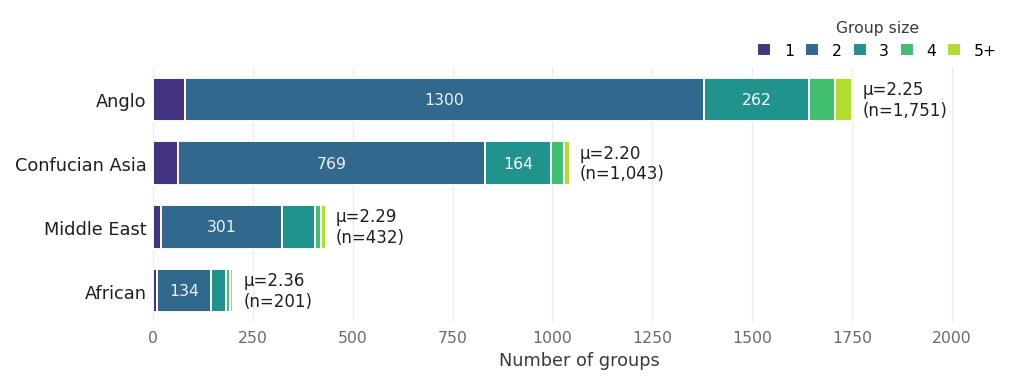

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


AN_values, AN_counts = np.unique(AN, return_counts=True)
AN_count_values = dict(zip(AN_values, AN_counts))

ME_values, ME_counts = np.unique(ME, return_counts=True)
ME_count_values = dict(zip(ME_values, ME_counts))

CA_values, CA_counts = np.unique(CA, return_counts=True)
CA_count_values = dict(zip(CA_values, CA_counts))

AF_values, AF_counts = np.unique(AF, return_counts=True)
AF_count_values = dict(zip(AF_values, AF_counts))


print(AN_count_values)

data = {
    "Region": ["Anglo", "Middle East", "Confucian Asia", "African"],
    "Score 1": [AN_count_values[1], ME_count_values[1], CA_count_values[1], AF_count_values[1]],
    "Score 2": [AN_count_values[2], ME_count_values[2], CA_count_values[2], AF_count_values[2]],
    "Score 3": [AN_count_values[3], ME_count_values[3], CA_count_values[3], AF_count_values[3]],
    "Score 4": [AN_count_values[4], ME_count_values[4], CA_count_values[4], AF_count_values[4]],
    "Score 5": [AN_count_values[5], ME_count_values[5], CA_count_values[5], AF_count_values[5]],
}

print(data)

counts = pd.DataFrame(data).set_index("Region")
score_values = pd.Series([1, 2, 3, 4, 5], index=counts.columns)
means = counts.mul(score_values, axis=1).sum(axis=1) / counts.sum(axis=1)

order = means.sort_values(ascending=True).index

order = ["Anglo", "Confucian Asia", "Middle East", "African"][::-1]

#print(order)
counts = counts.loc[order]
means = means.loc[order]
totals = counts.sum(axis=1)
proportions = counts.div(totals, axis=0) * 100

colors = plt.cm.viridis(np.linspace(0.15, 0.88, 5))
#colors = colors[::-1]

fig, ax = plt.subplots(figsize=(7.2, 2.5), dpi=150)
fig.patch.set_facecolor("white")

xmax = totals.max() * 1.22
MIN_LABEL_FRAC = 0.05

left = np.zeros(len(counts))
for i, col in enumerate(counts.columns):
    vals = counts[col].values
    ax.barh(counts.index, vals, left=left,
            color=colors[i], edgecolor="white", linewidth=0.9,
            height=0.68, label=col.replace("Score ", ""))
    for j, v in enumerate(vals):
        if v / xmax >= MIN_LABEL_FRAC:
            ax.text(left[j] + v / 2, j,  f"{int(v)}", #f"{proportions.iloc[j, i]:.0f}",
                    ha="center", va="center",
                    color="white" if i >= 2 else "#f0f0f0",
                    fontsize=7.5, fontweight="medium")
    left += vals

for i, region in enumerate(counts.index):
    ax.text(totals.iloc[i] + xmax * 0.012, i,
            f"μ={means.iloc[i]:.2f}\n(n={int(totals.iloc[i]):,})",
            va="center", ha="left",
            fontsize=8, color="#1f1f1f")

ax.set_xlim(0, xmax)
ax.set_xlabel("Number of groups", fontsize=8.5, color="#3a3a3a", labelpad=3)
ax.tick_params(axis="y", length=0, labelsize=8.5, colors="#1f1f1f", pad=3)
ax.tick_params(axis="x", length=0, labelsize=7.5, colors="#6a6a6a")
ax.set_axisbelow(True)
ax.xaxis.grid(True, color="#ececec", linewidth=0.6)
ax.yaxis.grid(False)
for s in ax.spines.values():
    s.set_visible(False)

legend_labels = ["1", "2", "3", "4", "5+"]

handles = [
    mpatches.Patch(
        facecolor=colors[i],
        edgecolor="white",
        label=legend_labels[i]
    )
    for i in range(5)
]

#handles = [mpatches.Patch(facecolor=colors[i], edgecolor="white", label=f"{i+1}")

#           for i in range(5)]

leg = ax.legend(handles=handles, title="Group size",
                loc="lower right", bbox_to_anchor=(1.0, 1.0),
                ncol=5, frameon=False, handlelength=0.9, handleheight=0.9,
                columnspacing=0.7, fontsize=7.5, title_fontsize=7.5,
                borderaxespad=0.2)
leg.get_title().set_color("#3a3a3a")

ax.set_ylim(-0.5, len(counts) - 0.5)
plt.subplots_adjust(top=0.88, bottom=0.20, left=0.18, right=0.97)
plt.savefig("group_dist_rebuttal.pdf", bbox_inches="tight", pad_inches=0.05)
plt.show()

## FREQUENCY AND CONFIDENCES

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Data (approximate values from the image)
categories = np.arange(0,len(frequencies))

# COCO (3.5)
ours = frequencies
# Create the plot
plt.figure(figsize=(10, 6))

# Plot bar chart
plt.bar(categories, ours, width=1.0, alpha=0.8, edgecolor='black', linewidth=0.5)

# Customize the plot
plt.xlabel('Number of Groups', fontsize=12)
plt.ylabel('Frequency on Frames', fontsize=12)
plt.title('Aggregated Group frequency', fontsize=12)
plt.xticks(categories)
plt.yticks(np.arange(0, 195, 5))
plt.ylim(0, 195)
plt.xlim(-0.5, 30)
plt.grid(True, alpha=0.3, axis='y')
#plt.legend(loc='upper right', fontsize=10)

# Format y-axis as percentages
ax = plt.gca()
#ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))

plt.tight_layout()
plt.savefig('../results/finegrained_fig_annotations/Aggregated_Group_Frequency.pdf', format='pdf', bbox_inches='tight')
plt.show()

NameError: name 'frequencies' is not defined